## 1) โหลดข้อมูล (Data Ingestion)
อัปโหลดไฟล์ CSV จาก Scopus ทั้ง 10 ไฟล์เข้าสู่ Colab เพื่อเตรียมนำมารวมกัน

In [ ]:

import pandas as pd
import io
import os
import re
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob
import os

folder_path = '/content/drive/MyDrive/Datasci csv/'  # แก้ path ตามที่วางจริง

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

print("ไฟล์ที่เจอ:")
for f in csv_files:
    print("-", os.path.basename(f))

ไฟล์ที่เจอ:
- scopus_export_Ai.csv
- scopus_export_ComMath.csv
- scopus_export_ComGraphicsDesign.csv
- scopus_export_ComNetworks.csv
- scopus_export_ComScienceApp.csv
- scopus_export_ComVision.csv
- scopus_export_Hardware.csv
- scopus_export_HumanComInteraction.csv
- scopus_export_InformationSystems.csv
- scopus_export_Software.csv


รวม (concat) ทั้ง 10 ไฟล์เป็น DataFrame เดียว พร้อมเก็บชื่อไฟล์ต้นทางไว้ในคอลัมน์ `Source_File` เพื่อใช้ตรวจสอบย้อนกลับได้ว่าแต่ละแถวมาจากไฟล์ไหน

In [ ]:
import pandas as pd

dfs = []

for filepath in csv_files:

    filename = os.path.basename(filepath)
    print(f"\nกำลังอ่าน: {filename}")

    try:
        df_temp = pd.read_csv(
            filepath,
            encoding='utf-8'
        )

    except UnicodeDecodeError:
        df_temp = pd.read_csv(
            filepath,
            encoding='latin1'
        )

    # เพิ่มชื่อไฟล์ต้นทาง
    df_temp['Source_File'] = filename

    dfs.append(df_temp)

# รวมทั้ง 10 ไฟล์
df = pd.concat(
    dfs,
    ignore_index=True
)

print("\n==============================")
print("รวมข้อมูลเรียบร้อย")
print("==============================")
print("จำนวนแถว:", len(df))
print("จำนวนคอลัมน์:", len(df.columns))


กำลังอ่าน: scopus_export_Ai.csv

กำลังอ่าน: scopus_export_ComMath.csv

กำลังอ่าน: scopus_export_ComGraphicsDesign.csv

กำลังอ่าน: scopus_export_ComNetworks.csv

กำลังอ่าน: scopus_export_ComScienceApp.csv

กำลังอ่าน: scopus_export_ComVision.csv

กำลังอ่าน: scopus_export_Hardware.csv

กำลังอ่าน: scopus_export_HumanComInteraction.csv

กำลังอ่าน: scopus_export_InformationSystems.csv

กำลังอ่าน: scopus_export_Software.csv

รวมข้อมูลเรียบร้อย
จำนวนแถว: 6000
จำนวนคอลัมน์: 23


## 2) สำรวจโครงสร้างข้อมูลเบื้องต้น (Initial EDA)
ดูรายชื่อคอลัมน์ทั้งหมด และนับจำนวนข้อมูลต่อไฟล์ เพื่อให้เห็นภาพรวมว่าข้อมูลแต่ละสาขา (แต่ละไฟล์) มีสัดส่วนเท่าไร

In [ ]:
print("Columns ทั้งหมด")
print("==============================")

for i, col in enumerate(df.columns):
    print(i, ":", col)

Columns ทั้งหมด
0 : Authors
1 : Author full names
2 : Author(s) ID
3 : Title
4 : Year
5 : Source title
6 : Volume
7 : Issue
8 : Art. No.
9 : Page start
10 : Page end
11 : Cited by
12 : DOI
13 : Link
14 : Abstract
15 : Author Keywords
16 : Index Keywords
17 : Document Type
18 : Publication Stage
19 : Open Access
20 : Source
21 : EID
22 : Source_File


In [ ]:
file_count = (
    df['Source_File']
    .value_counts()
    .sort_index()
)

print(file_count)

Source_File
scopus_export_Ai.csv                     600
scopus_export_ComGraphicsDesign.csv      600
scopus_export_ComMath.csv                600
scopus_export_ComNetworks.csv            600
scopus_export_ComScienceApp.csv          600
scopus_export_ComVision.csv              600
scopus_export_Hardware.csv               600
scopus_export_HumanComInteraction.csv    600
scopus_export_InformationSystems.csv     600
scopus_export_Software.csv               600
Name: count, dtype: int64


In [ ]:
file_summary = pd.DataFrame({
    'File': file_count.index,
    'Records': file_count.values
})

file_summary

,File,Records
0,scopus_export_Ai.csv,600
1,scopus_export_ComGraphicsDesign.csv,600
2,scopus_export_ComMath.csv,600
3,scopus_export_ComNetworks.csv,600
4,scopus_export_ComScienceApp.csv,600
5,scopus_export_ComVision.csv,600
6,scopus_export_Hardware.csv,600
7,scopus_export_HumanComInteraction.csv,600
8,scopus_export_InformationSystems.csv,600
9,scopus_export_Software.csv,600


ตรวจชนิดข้อมูล (dtypes) และค่าที่หายไป (missing values) ของทุกคอลัมน์ — เป็นขั้นตอน EDA มาตรฐานก่อนทำความสะอาดข้อมูล

In [ ]:
print("Shape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

missing_summary = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Missing_%': (df.isnull().mean() * 100).round(2)
})

missing_summary

Shape: (6000, 23)

Data Types
Authors              object
Author full names    object
Author(s) ID         object
Title                object
Year                  int64
Source title         object
Volume               object
Issue                object
Art. No.             object
Page start           object
Page end             object
Cited by              int64
DOI                  object
Link                 object
Abstract             object
Author Keywords      object
Index Keywords       object
Document Type        object
Publication Stage    object
Open Access          object
Source               object
EID                  object
Source_File          object
dtype: object

Missing Values
Authors                 0
Author full names       0
Author(s) ID            0
Title                   0
Year                    0
Source title            0
Volume                 11
Issue                1427
Art. No.             1555
Page start           4467
Page end             4470
Cited by  

,Missing,Missing_%
Authors,0,0.00
Author full names,0,0.00
Author(s) ID,0,0.00
Title,0,0.00
Year,0,0.00
Source title,0,0.00
Volume,11,0.18
Issue,1427,23.78
Art. No.,1555,25.92
Page start,4467,74.45


ตรวจสอบจำนวนแถวที่ซ้ำกันทั้งหมด (`duplicated()`) และจำนวน `EID` ที่ซ้ำกัน — เป็นการสำรวจหาข้อมูลซ้ำก่อนตัดสินใจว่าจะจัดการอย่างไร

In [ ]:
print("จำนวนแถวซ้ำทั้งหมด:",
      df.duplicated().sum())

if 'EID' in df.columns:

    print(
        "EID ซ้ำ:",
        df['EID'].duplicated().sum()
    )

จำนวนแถวซ้ำทั้งหมด: 0
EID ซ้ำ: 295


## 3) ทำความสะอาดข้อมูล (Data Cleaning)
สร้างคอลัมน์ `Subject` จากชื่อไฟล์ต้นทาง (`Source_File`) เพื่อใช้เป็น **label** สำหรับงาน classification ในขั้นตอนถัดไป

In [ ]:
df['Subject'] = (
    df['Source_File']
    .str.replace('.csv', '', regex=False)
    .str.strip()
)

df[['Source_File', 'Subject']].drop_duplicates()

,Source_File,Subject
0,scopus_export_Ai.csv,scopus_export_Ai
600,scopus_export_ComMath.csv,scopus_export_ComMath
1200,scopus_export_ComGraphicsDesign.csv,scopus_export_ComGraphicsDesign
1800,scopus_export_ComNetworks.csv,scopus_export_ComNetworks
2400,scopus_export_ComScienceApp.csv,scopus_export_ComScienceApp
3000,scopus_export_ComVision.csv,scopus_export_ComVision
3600,scopus_export_Hardware.csv,scopus_export_Hardware
4200,scopus_export_HumanComInteraction.csv,scopus_export_HumanComInteraction
4800,scopus_export_InformationSystems.csv,scopus_export_InformationSystems
5400,scopus_export_Software.csv,scopus_export_Software


ตรวจสอบว่ามีบทความ (EID) ใดปรากฏอยู่มากกว่า 1 Subject หรือไม่ (กรณีบทความเดียวกันถูกเก็บซ้ำในหลายไฟล์/หลายสาขา) เพราะถ้าปล่อยไว้จะทำให้ label ขัดแย้งกันเอง

In [ ]:
subject_count = (
    df.groupby('EID')['Subject']
      .nunique()
)

multi_subject_eid = subject_count[
    subject_count > 1
].index

print(
    "จำนวนบทความที่พบมากกว่า 1 Subject:",
    len(multi_subject_eid)
)

multi_subject_df = df[
    df['EID'].isin(multi_subject_eid)
].sort_values('EID')

multi_subject_df[
    ['EID', 'Title', 'Subject']
].head(50)

จำนวนบทความที่พบมากกว่า 1 Subject: 281


,EID,Title,Subject
2705,2-s2.0-105003752945,A Contemporary Algebraic Attributes of m-Polar...,scopus_export_ComScienceApp
865,2-s2.0-105003752945,A Contemporary Algebraic Attributes of m-Polar...,scopus_export_ComMath
3225,2-s2.0-105004697858,Gender Classification from Pashto Handwritten ...,scopus_export_ComVision
2984,2-s2.0-105004697858,Gender Classification from Pashto Handwritten ...,scopus_export_ComScienceApp
3024,2-s2.0-105014549301,Bringing Attention to CAD: Boundary Representa...,scopus_export_ComVision
1214,2-s2.0-105014549301,Bringing Attention to CAD: Boundary Representa...,scopus_export_ComGraphicsDesign
182,2-s2.0-105014601110,Integrating artificial intelligence and quantu...,scopus_export_Ai
3749,2-s2.0-105014601110,Integrating artificial intelligence and quantu...,scopus_export_Hardware
2969,2-s2.0-105022205159,Classification and Analysis of Packaging Desig...,scopus_export_ComScienceApp
3328,2-s2.0-105022205159,Classification and Analysis of Packaging Desig...,scopus_export_ComVision


ลบบทความที่มีมากกว่า 1 Subject ออกทั้งหมด เพื่อให้แต่ละบทความมี label ที่ชัดเจนไม่กำกวม ก่อนนำไปเทรนโมเดล

In [ ]:
before_multi_subject = len(df)

df_clean = df[
    ~df['EID'].isin(multi_subject_eid)
].copy()

after_multi_subject = len(df_clean)

print("ก่อนลบ:", before_multi_subject)
print("ลบออก:", before_multi_subject - after_multi_subject)
print("เหลือ:", after_multi_subject)

ก่อนลบ: 6000
ลบออก: 576
เหลือ: 5424


ตรวจสอบ Title ที่ซ้ำกัน แล้ว **ลบบทความที่ Title ซ้ำออก เหลือไว้แค่ 1 แถวต่อ Title** (เก็บแถวแรกที่เจอ) เพื่อป้องกันไม่ให้บทความเดียวกันหลุดไปอยู่ทั้งใน train set และ test set ตอนแบ่งข้อมูลทีหลัง (data leakage)

In [ ]:
df_clean['Title'] = (
    df_clean['Title']
    .fillna('')
    .astype(str)
    .str.strip()
)

duplicate_title = df_clean[
    df_clean.duplicated(
        subset='Title',
        keep=False
    )
].sort_values('Title')

print(
    "จำนวนแถวที่ Title ซ้ำ:",
    len(duplicate_title)
)

display(
    duplicate_title[
        ['Title', 'Subject', 'EID']
    ].head(50)
)

# แก้ไข: เดิมแค่ตรวจดูว่ามี Title ซ้ำเท่าไรแล้วจบ ไม่ได้ลบออกจริง
# ถ้าปล่อยไว้ บทความเดียวกัน (Title ซ้ำ) อาจไปอยู่ทั้งฝั่ง train และ
# test ตอน split ทำให้โมเดลเคยเห็นข้อมูลนั้นมาก่อนแล้ว วัด accuracy
# ได้สูงเกินจริง (data leakage) จึงต้องลบให้เหลือ Title ละ 1 แถว
before_dup_title = len(df_clean)

df_clean = df_clean.drop_duplicates(
    subset='Title',
    keep='first'
).copy()

print("ก่อนลบ Title ซ้ำ:", before_dup_title)
print("ลบออก:", before_dup_title - len(df_clean))
print("เหลือ:", len(df_clean))

จำนวนแถวที่ Title ซ้ำ: 4


,Title,Subject,EID
3832,ACALSim: A Scalable Parallel Simulation Framew...,scopus_export_Hardware,2-s2.0-105046362882
4169,ACALSim: A Scalable Parallel Simulation Framew...,scopus_export_Hardware,2-s2.0-105041128573
3732,Optimizing Dropout in LLM Training: Performanc...,scopus_export_Hardware,2-s2.0-105045966430
4199,Optimizing Dropout in LLM Training: Performanc...,scopus_export_Hardware,2-s2.0-105040931084


ก่อนลบ Title ซ้ำ: 5424
ลบออก: 2
เหลือ: 5422


จัดการ missing value ในคอลัมน์ `Abstract` (แทนที่ NaN ด้วยสตริงว่าง) และตัดช่องว่างหัวท้าย

In [ ]:
df_clean['Abstract'] = (
    df_clean['Abstract']
    .fillna('')
    .astype(str)
    .str.strip()
)

ตรวจสอบว่า Abstract มีข้อความ copyright/license ปนอยู่หรือไม่ แล้วเขียนฟังก์ชันตัดข้อความ copyright ทิ้งเฉพาะช่วงท้ายข้อความ (ป้องกันไม่ให้ตัดเนื้อหาจริงที่บังเอิญพูดถึงคำว่า copyright ไปด้วย) พร้อมสุ่มตรวจผลลัพธ์ด้วยตาก่อน-หลัง

In [ ]:
copyright_pattern = (
    r'copyright|©|all rights reserved|'
    r'creative commons|cc by|license'
)

copyright_rows = df_clean[
    df_clean['Abstract'].str.contains(
        copyright_pattern,
        case=False,
        regex=True,
        na=False
    )
]

print(
    "Abstract ที่อาจมี Copyright/License:",
    len(copyright_rows)
)

Abstract ที่อาจมี Copyright/License: 5402


In [ ]:
def clean_copyright(text, tail_window=250):

    if not text:
        return ''

    text = str(text)

    # แก้ไข: เดิม re.sub('copyright.*$', ...) จะตัดทุกอย่างหลังคำว่า
    # "copyright" ที่เจอ "ที่ไหนก็ได้" ในข้อความ ซึ่งถ้าบทความพูดถึง
    # copyright/license เป็นหัวข้อจริง ๆ (เช่นสาย Information Systems)
    # จะโดนตัดเนื้อหาที่เหลือทั้งหมดทิ้งไปด้วย
    #
    # แก้โดยจำกัดขอบเขตการค้นหาเฉพาะ "ท้ายข้อความ" (tail_window ตัวอักษร
    # สุดท้าย) เพราะ copyright footer ของ Elsevier/Scopus จะอยู่ท้าย
    # abstract เสมอ ส่วนต้นข้อความจะไม่ถูกแตะต้อง

    if len(text) > tail_window:
        head, tail = text[:-tail_window], text[-tail_window:]
    else:
        head, tail = '', text

    # ตัดตั้งแต่สัญลักษณ์ © ไปจนจบ (เฉพาะในช่วงท้ายข้อความ)
    tail = re.sub(r'©.*$', '', tail, flags=re.IGNORECASE)

    # ตัดตั้งแต่คำว่า "copyright" ไปจนจบ (เฉพาะในช่วงท้ายข้อความ)
    tail = re.sub(r'copyright\b.*$', '', tail, flags=re.IGNORECASE)

    # ตัดวลี "All rights reserved." ที่หลงเหลืออยู่
    tail = re.sub(r'all rights reserved\.?', '', tail, flags=re.IGNORECASE)

    return (head + tail).strip()


df_clean['Abstract'] = (
    df_clean['Abstract']
    .apply(clean_copyright)
)


In [ ]:
# ตรวจสอบผลลัพธ์การตัด copyright แบบสุ่ม เทียบก่อน-หลัง
# (ควรเช็คด้วยตาว่าไม่ได้ตัดเนื้อหาจริงทิ้งไปโดยไม่ตั้งใจ)
sample_idx = df_clean.sample(min(10, len(df_clean)), random_state=0).index

for i in sample_idx:
    print("EID:", df_clean.loc[i, 'EID'] if 'EID' in df_clean.columns else i)
    print("Abstract (after clean):", df_clean.loc[i, 'Abstract'][-200:])
    print("-" * 60)

df_clean[['Title', 'Abstract']].head(10)


EID: 2-s2.0-105036414508
Abstract (after clean): nd accountability in public administration. Moreover, the proposed approach helps prioritize oversight efforts by directing investigations toward cases with a higher probability of irregular behavior.
------------------------------------------------------------
EID: 2-s2.0-105045851663
Abstract (after clean):  The findings also demonstrate that an appropriate selection of the spectral characteristics of LED light sources can achieve a balance between energy efficiency and the mitigation of light pollution.
------------------------------------------------------------
EID: 2-s2.0-105035056748
Abstract (after clean): It acts as the first bibliometric study specifically focused on the intersection of privacy-preserving mechanisms and data-driven IIoT, providing actionable insights for researchers and practitioners.
------------------------------------------------------------
EID: 2-s2.0-105046196429
Abstract (after clean): s, indicating that

,Title,Abstract
0,AI-agent–empowered edge–IoT framework for pers...,The integration of Artificial Intelligence (AI...
1,Toward a robust and generalizable metamaterial...,Advances in material functionalities drive inn...
2,Artificial intelligence assisted colorectal le...,Computer-aided colonoscopy (CAC) may improve p...
3,Improving generalization of polyp detection vi...,Colorectal cancer outcomes are critically depe...
4,A Comprehensive Dataset of Lipid Nanoparticle ...,Lipid nanoparticles (LNPs) have emerged as the...
5,Artificial Intelligence-powered tiered early w...,Alert fatigue remains a major barrier to the e...
7,Mapping AI regulation in health care with the ...,Artificial intelligence (AI) policy for health...
9,Vib-ner: a model for out-of-vocabulary recogni...,The cybersecurity defense strategy of “proacti...
10,A prescriptive generative AI maturity model fo...,"Purpose – This study introduces CLIMB2-OLIMP, ..."
11,Human-AI collaboration in higher education: Ex...,Drawing on expectation confirmation theory (EC...


## 4) ตรวจจับและกรองภาษา (Language Filtering)

In [ ]:
!pip install langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from langdetect import detect, DetectorFactory

# แก้ไข: langdetect ใช้ random seed ภายใน ถ้าไม่ fix seed ผลลัพธ์การ
# ตรวจจับภาษาของข้อความสั้น ๆ/กำกวม (เช่น Title) อาจไม่เหมือนเดิม
# ทุกครั้งที่รัน ทำให้ reproducibility มีปัญหา
DetectorFactory.seed = 0

def detect_language(text):

    try:
        if not text or len(text.strip()) < 5:
            return 'unknown'

        return detect(text)

    except:
        return 'unknown'


df_clean['Title_Language'] = (
    df_clean['Title']
    .apply(detect_language)
)


In [ ]:
df_clean['Title_Language'].value_counts()

,count
Title_Language,
en,5342
it,28
fr,10
ca,8
de,7
da,6
pt,4
ro,4
es,3


In [ ]:
non_english = df_clean[
    df_clean['Title_Language'] != 'en'
]

print(
    "จำนวน Title ที่ไม่ใช่ English:",
    len(non_english)
)

จำนวน Title ที่ไม่ใช่ English: 80


In [ ]:
before_language = len(df_clean)

df_clean = df_clean[
    df_clean['Title_Language'] == 'en'
].copy()

print("ก่อน:", before_language)
print("หลัง:", len(df_clean))
print("ลบ:", before_language - len(df_clean))

ก่อน: 5422
หลัง: 5342
ลบ: 80


## 5) เตรียมข้อความสำหรับสร้าง Embedding (Feature Engineering)

In [ ]:
text_columns = [
    'Title',
    'Abstract',
    'Author Keywords',
    'Index Keywords'
]

for col in text_columns:

    if col in df_clean.columns:

        df_clean[col] = (
            df_clean[col]
            .fillna('')
            .astype(str)
            .str.strip()
        )

In [ ]:
# แก้ไข: เดิมต่อ Title/Abstract/Keywords ด้วย space เฉย ๆ ทำให้ไม่มี
# ขอบเขตชัดเจนระหว่างแต่ละ field เวลาโมเดล tokenize
# ใช้ " [SEP] " คั่น (ตรงกับ token พิเศษของโมเดลตระกูล BERT/SPECTER2
# ที่จะใช้ตอน embedding ในขั้นถัดไป) เพื่อให้โมเดลแยกส่วน Title กับ
# Abstract/Keywords ออกจากกันได้ชัดเจนขึ้น
SEP = ' [SEP] '

df_clean['embedding_text'] = (
    df_clean['Title'] + SEP +
    df_clean['Abstract'] + SEP +
    df_clean['Author Keywords'] + SEP +
    df_clean['Index Keywords']
)


In [ ]:
df_clean[
    [
        'Title',
        'Abstract',
        'Author Keywords',
        'Index Keywords',
        'embedding_text'
    ]
].head(3)

,Title,Abstract,Author Keywords,Index Keywords,embedding_text
0,AI-agent–empowered edge–IoT framework for pers...,The integration of Artificial Intelligence (AI...,,Anomaly detection; Artificial intelligence; Da...,AI-agent–empowered edge–IoT framework for pers...
1,Toward a robust and generalizable metamaterial...,Advances in material functionalities drive inn...,,Artificial intelligence; Inverse problems; Mat...,Toward a robust and generalizable metamaterial...
2,Artificial intelligence assisted colorectal le...,Computer-aided colonoscopy (CAC) may improve p...,,Oncology; Patient treatment; Screening; Cancer...,Artificial intelligence assisted colorectal le...


In [ ]:
empty_text = df_clean[
    df_clean['embedding_text'].str.strip() == ''
]

print(
    "จำนวนข้อมูลที่ embedding_text ว่าง:",
    len(empty_text)
)

empty_text[
    ['Title', 'Abstract',
     'Author Keywords',
     'Index Keywords']
].head(20)

df_clean = df_clean[
    df_clean['embedding_text'].str.strip() != ''
].copy()

จำนวนข้อมูลที่ embedding_text ว่าง: 0


In [ ]:
print("=" * 50)
print("CLEANING SUMMARY")
print("=" * 50)

print("จำนวนข้อมูลเริ่มต้น :", len(df))

print(
    "หลัง Remove Multi-Subject / Non-English / Empty embedding_text :",
    len(df_clean)
)

print(
    "จำนวน Column :",
    len(df_clean.columns)
)

# แก้ไข: เพิ่มรายชื่อคอลัมน์ใหม่ที่ pipeline สร้างขึ้นระหว่างทาง
# เพื่อให้ summary อ่านแล้วรู้ทันทีว่าคอลัมน์ที่เพิ่มมาคืออะไรบ้าง
new_columns = set(df_clean.columns) - set(df.columns)
print("คอลัมน์ที่เพิ่มขึ้นระหว่าง Cleaning :", sorted(new_columns))

print("=" * 50)


CLEANING SUMMARY
จำนวนข้อมูลเริ่มต้น : 6000
หลัง Remove Multi-Subject / Non-English / Empty embedding_text : 5342
จำนวน Column : 26
คอลัมน์ที่เพิ่มขึ้นระหว่าง Cleaning : ['Title_Language', 'embedding_text']


In [ ]:
output_file = 'scopus_cleaned.csv'

df_clean.to_csv(
    output_file,
    index=False,
    encoding='utf-8-sig'
)

print(
    "บันทึกไฟล์เรียบร้อย:",
    output_file
)

บันทึกไฟล์เรียบร้อย: scopus_cleaned.csv


In [ ]:
print("จำนวนข้อมูลหลัง Cleaning:", len(df_clean))
print("จำนวน Columns:", len(df_clean.columns))

display(df_clean.head())

จำนวนข้อมูลหลัง Cleaning: 5342
จำนวน Columns: 26


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID,Source_File,Subject,Title_Language,embedding_text
0,Yang S.,"Yang, Shengjie (60264453900)",60264453900,AI-agent–empowered edge–IoT framework for pers...,2026,Discover Internet of Things,6,1.0,39.0,NaN,...,Anomaly detection; Artificial intelligence; Da...,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105034394223,scopus_export_Ai.csv,scopus_export_Ai,en,AI-agent–empowered edge–IoT framework for pers...
1,Kim N.; Lee D.; Yu J.; Cho S.W.; Lee D.; Park ...,"Kim, Namjung (57222498602); Lee, Dongseok (580...",57222498602; 58094342400; 60007450800; 5722212...,Toward a robust and generalizable metamaterial...,2026,npj Computational Materials,12,1.0,54.0,NaN,...,Artificial intelligence; Inverse problems; Mat...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105028658878,scopus_export_Ai.csv,scopus_export_Ai,en,Toward a robust and generalizable metamaterial...
2,Lux T.J.; Saßmannshausen Z.; Kafetzis I.; Banc...,"Lux, Thomas J. (57540372000); Saßmannshausen, ...",57540372000; 57660584400; 57202816280; 5745384...,Artificial intelligence assisted colorectal le...,2026,npj Digital Medicine,9,1.0,284.0,NaN,...,Oncology; Patient treatment; Screening; Cancer...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105035618863,scopus_export_Ai.csv,scopus_export_Ai,en,Artificial intelligence assisted colorectal le...
3,Lin Y.; Huang C.; Tian H.; Yang B.; Deng T.; P...,"Lin, Yilin (57209668420); Huang, Cong (6036733...",57209668420; 60367331200; 60366910100; 5719292...,Improving generalization of polyp detection vi...,2026,npj Digital Medicine,9,1.0,113.0,NaN,...,Computer aided diagnosis; Screening; Annotated...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105029080616,scopus_export_Ai.csv,scopus_export_Ai,en,Improving generalization of polyp detection vi...
4,Song S.; Baek J.; Seo S.,"Song, Seunghun (58087920400); Baek, Jueun (603...",58087920400; 60362225400; 36350296100,A Comprehensive Dataset of Lipid Nanoparticle ...,2026,Scientific Data,13,1.0,139.0,NaN,...,Drug Delivery Systems; Humans; Lipids; Liposom...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105028978303,scopus_export_Ai.csv,scopus_export_Ai,en,A Comprehensive Dataset of Lipid Nanoparticle ...


## 6) เลือกคอลัมน์ที่จำเป็น (รวม embedding_text ที่ทำไว้แล้ว)
เลือกเฉพาะคอลัมน์ที่จะใช้ต่อจาก `df_clean` มาเก็บใน `selected_df` โดยดึง `embedding_text` ที่ผ่านการทำความสะอาดแล้วจากขั้นตอนที่ 5 มาด้วยเลย (เดิม `selected_columns` ไม่มี `embedding_text` และไม่มีการสร้างขึ้นใหม่ ทำให้เซลล์ถัดไปที่เรียกใช้คอลัมน์นี้จะ error)

In [ ]:
selected_columns = [
    'EID',
    'Title',
    'Abstract',
    'Author Keywords',
    'Index Keywords',
    'Subject',
    'embedding_text'
]

selected_df = df_clean[selected_columns].copy()

display(selected_df.head())

,EID,Title,Abstract,Author Keywords,Index Keywords,Subject,embedding_text
0,2-s2.0-105034394223,AI-agent–empowered edge–IoT framework for pers...,The integration of Artificial Intelligence (AI...,,Anomaly detection; Artificial intelligence; Da...,scopus_export_Ai,AI-agent–empowered edge–IoT framework for pers...
1,2-s2.0-105028658878,Toward a robust and generalizable metamaterial...,Advances in material functionalities drive inn...,,Artificial intelligence; Inverse problems; Mat...,scopus_export_Ai,Toward a robust and generalizable metamaterial...
2,2-s2.0-105035618863,Artificial intelligence assisted colorectal le...,Computer-aided colonoscopy (CAC) may improve p...,,Oncology; Patient treatment; Screening; Cancer...,scopus_export_Ai,Artificial intelligence assisted colorectal le...
3,2-s2.0-105029080616,Improving generalization of polyp detection vi...,Colorectal cancer outcomes are critically depe...,,Computer aided diagnosis; Screening; Annotated...,scopus_export_Ai,Improving generalization of polyp detection vi...
4,2-s2.0-105028978303,A Comprehensive Dataset of Lipid Nanoparticle ...,Lipid nanoparticles (LNPs) have emerged as the...,,Drug Delivery Systems; Humans; Lipids; Liposom...,scopus_export_Ai,A Comprehensive Dataset of Lipid Nanoparticle ...


In [ ]:
display(
    selected_df[
        [
            'Title',
            'Abstract',
            'Author Keywords',
            'Index Keywords',
            'embedding_text'
        ]
    ].head(3)
)

,Title,Abstract,Author Keywords,Index Keywords,embedding_text
0,AI-agent–empowered edge–IoT framework for pers...,The integration of Artificial Intelligence (AI...,,Anomaly detection; Artificial intelligence; Da...,AI-agent–empowered edge–IoT framework for pers...
1,Toward a robust and generalizable metamaterial...,Advances in material functionalities drive inn...,,Artificial intelligence; Inverse problems; Mat...,Toward a robust and generalizable metamaterial...
2,Artificial intelligence assisted colorectal le...,Computer-aided colonoscopy (CAC) may improve p...,,Oncology; Patient treatment; Screening; Cancer...,Artificial intelligence assisted colorectal le...


## 7) โหลดโมเดล SPECTER2 สำหรับสร้าง Document Embedding

In [ ]:

!pip install -q -U transformers adapters tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import torch
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

# แก้ไข: เพิ่มการเช็ค GPU อัตโนมัติ ถ้า Colab เปิด GPU ไว้ (Runtime > Change runtime type > T4 GPU) โค้ดจะย้าย model ไปรันบน GPU ให้เอง ถ้าไม่มี GPU ก็ fallback ไปใช้ CPU แทนโดยไม่ error
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_name = "allenai/specter2_base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# แก้ไข: เดิมโหลดด้วย AutoModel.from_pretrained(model_name) เฉย ๆ ซึ่ง
# allenai/specter2_base เป็นเพียง base encoder เท่านั้น ยังไม่ใช่โมเดลที่
# ให้ document embedding ตามที่ SPECTER2 ออกแบบไว้ ต้องโหลด "adapter"
# (proximity adapter) ทับอีกชั้นก่อน ถึงจะได้ embedding ที่ถูกต้องสำหรับ
# งานเปรียบเทียบความคล้ายของบทความ (สาเหตุของ warning
# "You are using a model of type `bert` to instantiate a model of type ``"
# ที่ขึ้นตอนรันของเดิม)
model = AutoAdapterModel.from_pretrained(model_name)
model.load_adapter(
    "allenai/specter2",
    source="hf",
    load_as="specter2_proximity",
    set_active=True
)

# แก้ไข: ย้าย model ไปที่ device (GPU ถ้ามี) ก่อนใช้งาน
model = model.to(device)
model.eval()

Device: cuda


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

adapter_config.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

pytorch_adapter.bin:   0%|          | 0.00/3.59M [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

BertAdapterModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31090, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttentionWithAdapters(
              (query): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (key): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (value): LoRALinearTorch(
             

In [ ]:
text = selected_df.iloc[0]['embedding_text']

inputs = tokenizer(
    text,
    return_tensors='pt',
    truncation=True,
    max_length=512
)

# แก้ไข: ย้าย inputs ไปที่ device เดียวกับ model (GPU ถ้ามี)
# ไม่งั้นจะ error เพราะ model กับ inputs อยู่คนละอุปกรณ์กัน
inputs = {key: value.to(device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

embedding = outputs.last_hidden_state[:, 0, :]

print("Embedding shape:", embedding.shape)

Embedding shape: torch.Size([1, 768])


สร้างฟังก์ชันสร้าง embedding แบบเป็น batch (ประมวลผลทีละกลุ่มแทนทีละแถว เพื่อความเร็ว) แล้วรันกับข้อมูลทั้งหมดเพื่อแปลงทุกบทความเป็นเวกเตอร์ตัวเลข

In [ ]:
from tqdm.auto import tqdm

def create_embeddings(
    texts,
    batch_size=16,
    max_length=512
):

    all_embeddings = []

    for i in tqdm(
        range(0, len(texts), batch_size)
    ):

        batch_texts = texts[
            i:i + batch_size
        ]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

        # แก้ไข: ย้าย inputs ไปที่ device เดียวกับ model (GPU ถ้ามี)
        # เพื่อให้การสร้าง embedding ทั้งชุดข้อมูลรันบน GPU จริง ๆ
        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.no_grad():
            outputs = model(**inputs)

        # ใช้ representation ของ token แรก
        batch_embeddings = (
            outputs
            .last_hidden_state[:, 0, :]
        )

        # แก้ไข: .cpu() ยังจำเป็นอยู่ แม้รันบน GPU เพราะต้องย้ายผลลัพธ์
        # กลับมาที่ CPU ก่อนค่อย torch.cat / แปลงเป็น numpy ทีหลัง
        all_embeddings.append(
            batch_embeddings.cpu()
        )

    return torch.cat(
        all_embeddings,
        dim=0
    )

In [ ]:
texts = selected_df[
    'embedding_text'
].tolist()

embeddings = create_embeddings(
    texts,
    batch_size=16
)

print("Embedding shape:")
print(embeddings.shape)

  0%|          | 0/334 [00:00<?, ?it/s]

Embedding shape:
torch.Size([5342, 768])


In [ ]:
print(embeddings.shape)

torch.Size([5342, 768])


## 8) เตรียมข้อมูลให้พร้อมสำหรับ Machine Learning
ทำ L2-normalize เวกเตอร์ embedding (ให้ทุกเวกเตอร์มีขนาดหน่วยเท่ากัน ซึ่งช่วยให้โมเดล linear เช่น Logistic Regression เรียนรู้ได้ดีขึ้น) แล้วแปลงเป็น numpy array `X` เพื่อใช้เป็น input ของโมเดล

In [ ]:
import torch.nn.functional as F

embeddings_normalized = F.normalize(
    embeddings,
    p=2,
    dim=1
)

print(
    embeddings_normalized.shape
)

torch.Size([5342, 768])


In [ ]:
X = embeddings_normalized.numpy()

print("X shape:", X.shape)

X shape: (5342, 768)


In [ ]:
y = selected_df[
    'Subject'
].values

print("จำนวน Label:", len(y))

จำนวน Label: 5342


แบ่งข้อมูลเป็น train/test (80/20) แบบ stratify ตาม label เพื่อรักษาสัดส่วนของแต่ละ Subject ให้เท่ากันทั้งสองฝั่ง

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4273, 768)
X_test : (1069, 768)
y_train: (4273,)
y_test : (1069,)


## 9) เทรนโมเดลและประเมินผล (Model Training & Evaluation)
เทรน Logistic Regression บนเวกเตอร์ embedding แล้วทำนายผลกับ test set จากนั้นวัดผลด้วย accuracy และ classification report (precision/recall/F1 รายคลาส)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000
)

clf.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.6323666978484564
                                   precision    recall  f1-score   support

                 scopus_export_Ai       0.56      0.65      0.60       100
  scopus_export_ComGraphicsDesign       0.79      0.84      0.81       117
            scopus_export_ComMath       0.78      0.89      0.83       117
        scopus_export_ComNetworks       0.67      0.69      0.68       101
      scopus_export_ComScienceApp       0.45      0.22      0.29       110
          scopus_export_ComVision       0.58      0.84      0.69       115
           scopus_export_Hardware       0.67      0.70      0.68       108
scopus_export_HumanComInteraction       0.55      0.51      0.53       103
 scopus_export_InformationSystems       0.41      0.26      0.32        96
           scopus_export_Software       0.65      0.63      0.64       102

                         accuracy                           0.63      1069
                        macro avg       0.61      0.62      0.61     

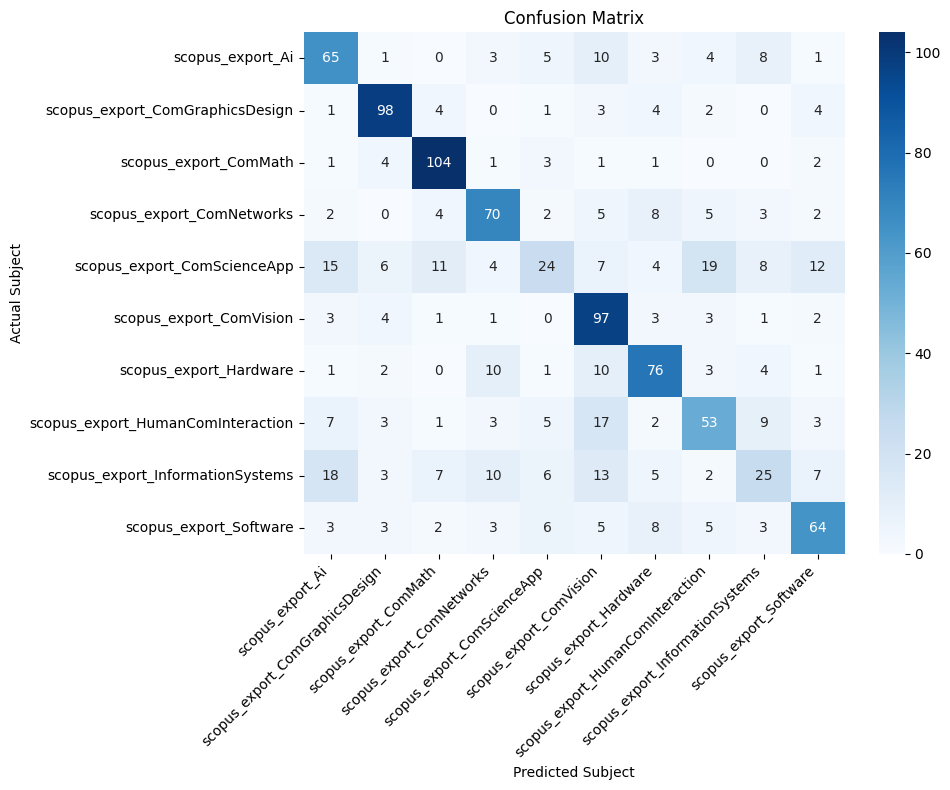

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=clf.classes_,
    yticklabels=clf.classes_,
    cmap='Blues'
)
plt.xlabel('Predicted Subject')
plt.ylabel('Actual Subject')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10) บันทึกผลลัพธ์
บันทึกเวกเตอร์ embedding (`.npy`) และตาราง DataFrame ที่มี embedding_text (`.csv`) ไว้ใช้งานต่อ

In [ ]:
import numpy as np

np.save(
    'specter2_embeddings.npy',
    X
)

In [ ]:
selected_df.to_csv(
    'scopus_cleaned_with_embedding_text.csv',
    index=False,
    encoding='utf-8-sig'
)